## 1. Setup and Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, deque
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# NLP and text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD

# Machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Metrics and evaluation
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import train_test_split

# Dataset
from datasets import load_dataset

# Set random seed for reproducibility
np.random.seed(42)

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## 2. Load AG News Dataset

In [2]:
# Load AG News dataset from HuggingFace
print("Loading AG News dataset from HuggingFace...")
dataset = load_dataset("fancyzhx/ag_news")

# Convert to pandas DataFrames
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# Subsample to requested sizes
train_df = train_df.sample(n=9500, random_state=42).reset_index(drop=True)
test_df = test_df.sample(n=3420, random_state=42).reset_index(drop=True)

# Define class labels
class_names = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
train_df['label_name'] = train_df['label'].map(class_names)
test_df['label_name'] = test_df['label'].map(class_names)

print(f"Dataset loaded successfully!")
print(f"\nTrain set size: {len(train_df):,}")
print(f"Test set size: {len(test_df):,}")
print(f"\nClass labels: {class_names}")
print("\nFirst few samples:")
train_df.head()

Loading AG News dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset loaded successfully!

Train set size: 9,500
Test set size: 3,420

Class labels: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

First few samples:


,text,label,label_name
0,"BBC set for major shake-up, claims newspaper L...",2,Business
1,Marsh averts cash crunch Embattled insurance b...,2,Business
2,"Jeter, Yankees Look to Take Control (AP) AP - ...",1,Sports
3,Flying the Sun to Safety When the Genesis caps...,3,Sci/Tech
4,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,2,Business


## 3. Exploratory Data Analysis (EDA)

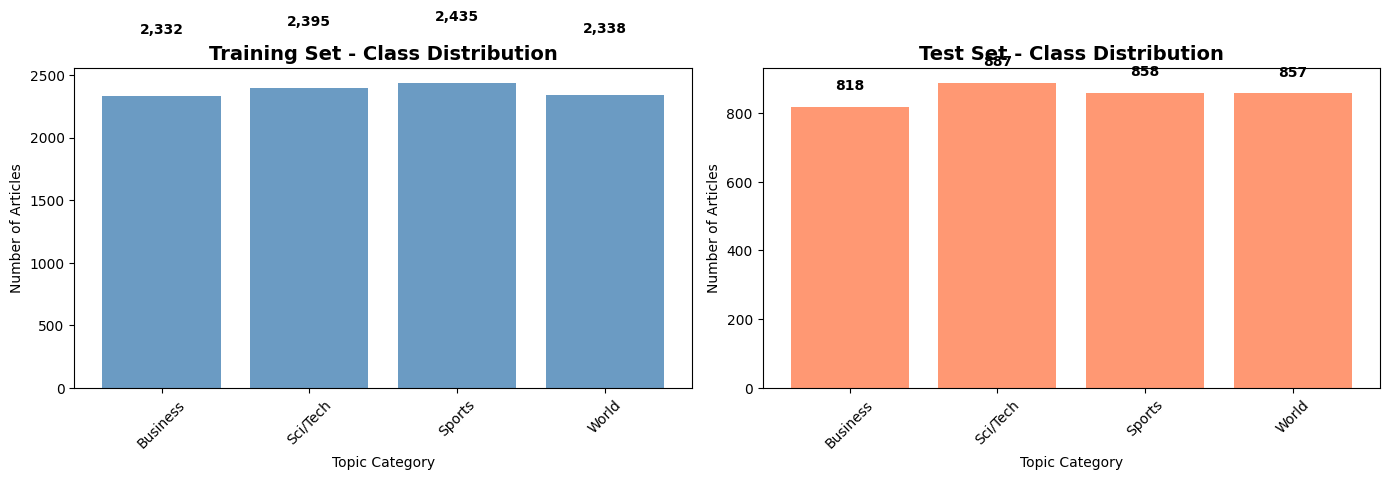

Class Distribution Statistics:

Training Set:
label_name
Business    2332
Sci/Tech    2395
Sports      2435
World       2338
Name: count, dtype: int64

Test Set:
label_name
Business    818
Sci/Tech    887
Sports      858
World       857
Name: count, dtype: int64


In [3]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set distribution
train_counts = train_df['label_name'].value_counts().sort_index()
axes[0].bar(train_counts.index, train_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Training Set - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Topic Category')
axes[0].set_ylabel('Number of Articles')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Test set distribution
test_counts = test_df['label_name'].value_counts().sort_index()
axes[1].bar(test_counts.index, test_counts.values, color='coral', alpha=0.8)
axes[1].set_title('Test Set - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Topic Category')
axes[1].set_ylabel('Number of Articles')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Class Distribution Statistics:")
print("\nTraining Set:")
print(train_df['label_name'].value_counts().sort_index())
print("\nTest Set:")
print(test_df['label_name'].value_counts().sort_index())

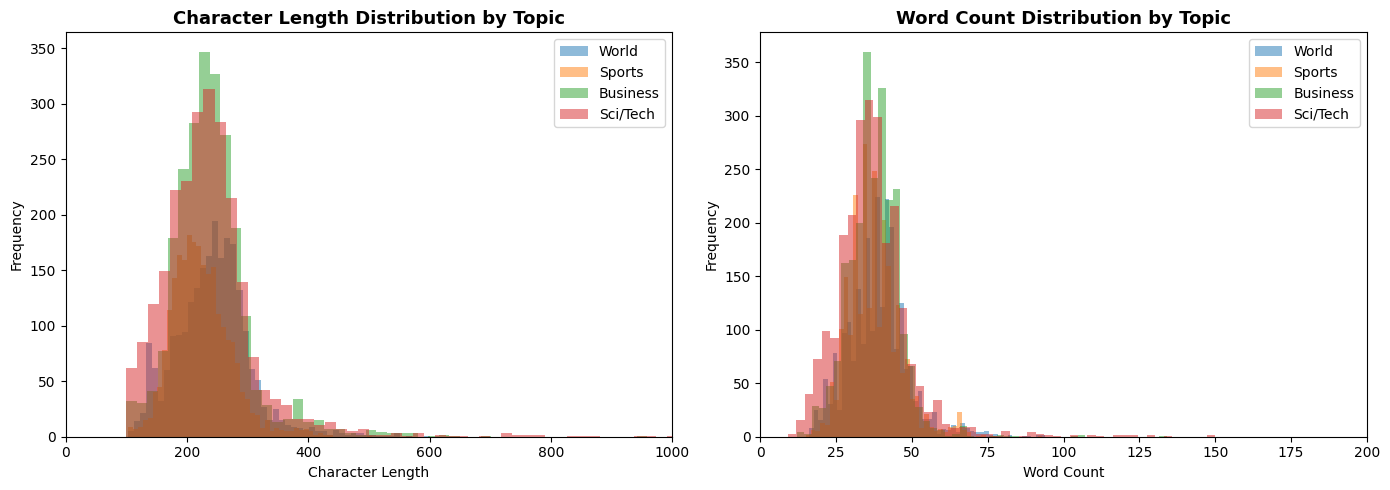


Text Statistics by Topic:
           text_length                                                     \
                 count    mean    std    min    25%    50%    75%     max   
label_name                                                                  
Business        2332.0  240.71  66.43  100.0  203.0  235.0  266.0   959.0   
Sci/Tech        2395.0  236.74  84.43  100.0  187.5  229.0  267.0  1009.0   
Sports          2435.0  223.89  49.07  103.0  190.0  219.0  251.0   505.0   
World           2338.0  243.06  62.60  102.0  204.0  243.0  276.0   601.0   

           word_count                                               
                count   mean    std   min   25%   50%   75%    max  
label_name                                                          
Business       2332.0  37.52   8.64  12.0  32.0  37.0  43.0  134.0  
Sci/Tech       2395.0  37.14  12.84   9.0  30.0  36.0  42.0  150.0  
Sports         2435.0  37.60   8.63  15.0  32.0  37.0  42.0   93.0  
World          2338

In [4]:
# Text length analysis
train_df['text_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution by class
for label_name in class_names.values():
    subset = train_df[train_df['label_name'] == label_name]
    axes[0].hist(subset['text_length'], bins=50, alpha=0.5, label=label_name)
axes[0].set_title('Character Length Distribution by Topic', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Word count distribution by class
for label_name in class_names.values():
    subset = train_df[train_df['label_name'] == label_name]
    axes[1].hist(subset['word_count'], bins=50, alpha=0.5, label=label_name)
axes[1].set_title('Word Count Distribution by Topic', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

print("\nText Statistics by Topic:")
print(train_df.groupby('label_name')[['text_length', 'word_count']].describe().round(2))

## 4. Text Preprocessing (NLP)

In [5]:
import nltk
nltk.download('all')
# Initialize preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Comprehensive text preprocessing pipeline
    - Lowercase conversion
    - Remove special characters and numbers
    - Tokenization
    - Remove stopwords
    - Lemmatization
    """
    # Lowercase
    text = text.lower()

    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens
              if token not in stop_words and len(token) > 2]

    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing training data...")
train_df['text_clean'] = train_df['text'].apply(preprocess_text)

print("Preprocessing test data...")
test_df['text_clean'] = test_df['text'].apply(preprocess_text)

print("\nText preprocessing completed!")
print("\nExample of preprocessing:")
print(f"\nOriginal:\n{train_df.iloc[0]['text'][:200]}...")
print(f"\nCleaned:\n{train_df.iloc[0]['text_clean'][:200]}...")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

Preprocessing training data...
Preprocessing test data...

Text preprocessing completed!

Example of preprocessing:

Original:
BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in th...

Cleaned:
bbc set major shakeup claim newspaper london british broadcasting corporation world biggest public broadcaster cut almost quarter strong workforce biggest shakeup year history time newspaper london sa...


## 5. Feature Extraction: Converting Text to Numerical Data

In [6]:
# TF-IDF Vectorization
print("Extracting TF-IDF features...")

# Using TF-IDF with optimized parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,      # Top 10k features
    ngram_range=(1, 2),      # Unigrams and bigrams
    min_df=5,                # Minimum document frequency
    max_df=0.8,              # Maximum document frequency
    sublinear_tf=True        # Apply sublinear tf scaling
)

# Fit on training data and transform both sets
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['text_clean'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['text_clean'])

# Extract labels
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"\nFeature extraction completed!")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Test features shape: {X_test_tfidf.shape}")
print(f"Feature dimensionality: {X_train_tfidf.shape[1]:,} features")
print(f"Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")

Extracting TF-IDF features...

Feature extraction completed!
Training features shape: (9500, 8275)
Test features shape: (3420, 8275)
Feature dimensionality: 8,275 features
Sparsity: 99.75%


## 6. Baseline Classification Models

In [8]:
# Define multiple classifiers for comparison
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42),
    'SGD Classifier': SGDClassifier(max_iter=1000, random_state=42)
}

# Train and evaluate each classifier
baseline_results = {}

print("Training baseline classifiers...\n")

for name, clf in classifiers.items():
    print(f"\n{name}")

    # Train
    clf.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = clf.predict(X_test_tfidf)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    # Store results
    baseline_results[name] = {
        'model': clf,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision': precision,
        'recall': recall,
        'predictions': y_pred
    }

    print(f"Accuracy:          {accuracy:.4f}")
    print(f"F1 (Macro):        {f1_macro:.4f}")
    print(f"F1 (Weighted):     {f1_weighted:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")

Training baseline classifiers...


Naive Bayes
Accuracy:          0.8860
F1 (Macro):        0.8853
F1 (Weighted):     0.8856
Precision:         0.8855
Recall:            0.8860

Logistic Regression
Accuracy:          0.8895
F1 (Macro):        0.8888
F1 (Weighted):     0.8891
Precision:         0.8892
Recall:            0.8895

Linear SVM
Accuracy:          0.8868
F1 (Macro):        0.8862
F1 (Weighted):     0.8865
Precision:         0.8865
Recall:            0.8868

SGD Classifier
Accuracy:          0.8927
F1 (Macro):        0.8920
F1 (Weighted):     0.8923
Precision:         0.8923
Recall:            0.8927


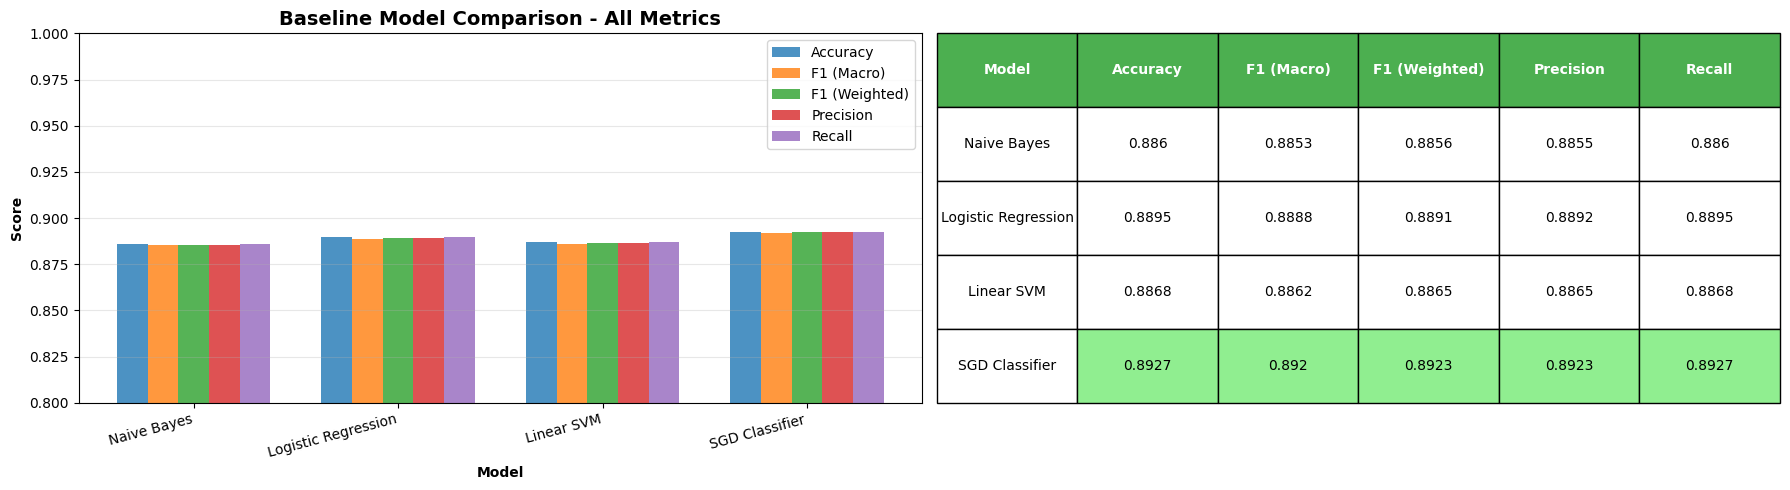


Baseline Results Summary:


,Model,Accuracy,F1 (Macro),F1 (Weighted),Precision,Recall
0,Naive Bayes,0.8860,0.8853,0.8856,0.8855,0.8860
1,Logistic Regression,0.8895,0.8888,0.8891,0.8892,0.8895
2,Linear SVM,0.8868,0.8862,0.8865,0.8865,0.8868
3,SGD Classifier,0.8927,0.8920,0.8923,0.8923,0.8927


In [11]:
# Visualize baseline results
results_df = pd.DataFrame({
    'Model': list(baseline_results.keys()),
    'Accuracy': [v['accuracy'] for v in baseline_results.values()],
    'F1 (Macro)': [v['f1_macro'] for v in baseline_results.values()],
    'F1 (Weighted)': [v['f1_weighted'] for v in baseline_results.values()],
    'Precision': [v['precision'] for v in baseline_results.values()],
    'Recall': [v['recall'] for v in baseline_results.values()]
})

# Create comparison plot
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar chart of all metrics
x = np.arange(len(results_df))
width = 0.15
metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'Precision', 'Recall']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric], width, label=metric, color=colors[i], alpha=0.8)

axes[0].set_xlabel('Model', fontweight='bold')
axes[0].set_ylabel('Score', fontweight='bold')
axes[0].set_title('Baseline Model Comparison - All Metrics', fontsize=14, fontweight='bold')
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim(0.8, 1.0)
axes[0].grid(axis='y', alpha=0.3)

# Show table
axes[1].axis('tight')
axes[1].axis('off')
table = axes[1].table(cellText=results_df.round(4).values,
                      colLabels=results_df.columns,
                      cellLoc='center',
                      loc='center',
                      bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(len(results_df.columns)):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Highlight best scores
for col_idx, col in enumerate(['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'Precision', 'Recall']):
    best_idx = results_df[col].idxmax() + 1
    table[(best_idx, col_idx + 1)].set_facecolor('#90EE90')

plt.tight_layout()
plt.show()

print("\nBaseline Results Summary:")
results_df.round(4)

Best Baseline Model: SGD Classifier
Accuracy: 0.8927


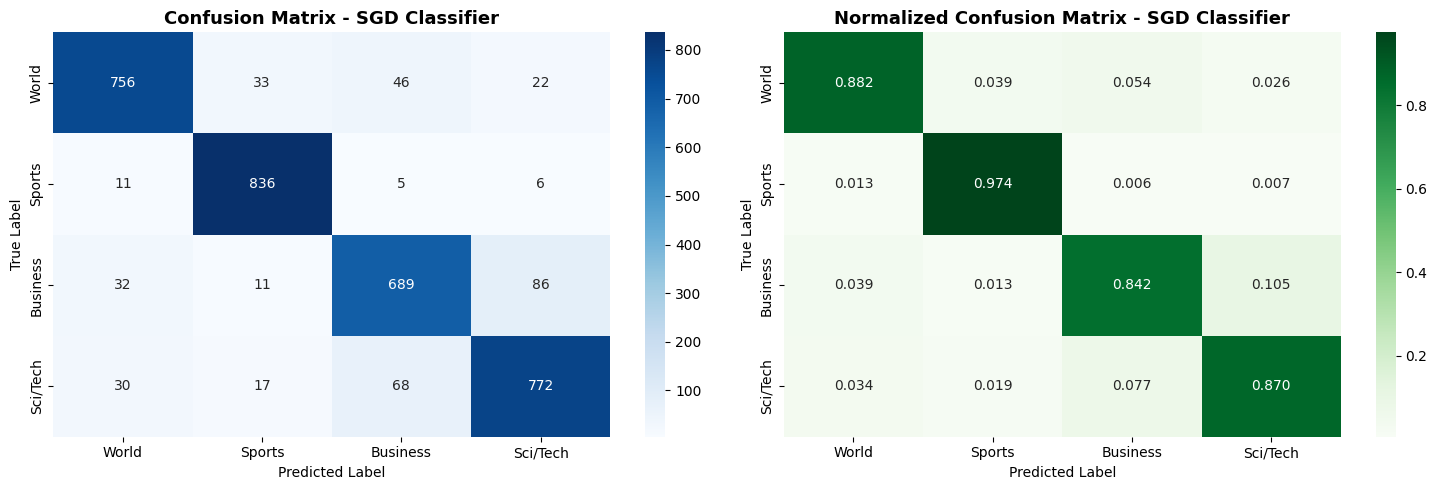


Detailed Classification Report - SGD Classifier:
              precision    recall  f1-score   support

       World       0.91      0.88      0.90       857
      Sports       0.93      0.97      0.95       858
    Business       0.85      0.84      0.85       818
    Sci/Tech       0.87      0.87      0.87       887

    accuracy                           0.89      3420
   macro avg       0.89      0.89      0.89      3420
weighted avg       0.89      0.89      0.89      3420



In [12]:
# Select best model for streaming evaluation
best_model_name = max(baseline_results.keys(), key=lambda k: baseline_results[k]['accuracy'])
best_model = baseline_results[best_model_name]['model']
best_predictions = baseline_results[best_model_name]['predictions']

print(f"Best Baseline Model: {best_model_name}")
print(f"Accuracy: {baseline_results[best_model_name]['accuracy']:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names.values(),
            yticklabels=class_names.values(),
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens',
            xticklabels=class_names.values(),
            yticklabels=class_names.values(),
            ax=axes[1])
axes[1].set_title(f'Normalized Confusion Matrix - {best_model_name}', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Detailed classification report
print(f"\nDetailed Classification Report - {best_model_name}:")
print(classification_report(y_test, best_predictions, target_names=class_names.values()))